In [1]:
import numpy as np
import pandas as pd
import talib
import matplotlib.pyplot as plt


Duplicate key in file PosixPath('/Users/aming/anaconda3/envs/tf_mac/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc'), line 277 (' font.sans-serif: Arial Unicode MS, DejaVu Sans')


In [2]:
def percentileofscore(a, score):
    a = np.asarray(a)
    n = len(a)
    score = np.asarray(score)
    # Prepare broadcasting
    score = score[..., None]
    def count(x):
        return np.count_nonzero(x, -1)
    
    left = count(a < score)
    right = count(a <= score)
    plus1 = left < right
    perct = np.ma.filled((left + right + plus1) * (50. / n), np.nan)
    return perct

In [3]:
a = [1,2,3,4,5]
score1 = 3
score2 = 2.5
pscore = percentileofscore(a, score1)
pscore2 = percentileofscore(a, score2)
print(pscore)
print(pscore2)


filled1 = np.ma.filled(np.array([np.inf, -1]), np.nan)
print(filled1)
# filled2 = np.ma.filled(0, np.nan)

60.0
40.0
[inf -1.]


In [4]:
df = pd.read_csv('/Users/aming/data/ETHUSDT/15m/2025/ETHUSDT-15m-2025-01.zip')
df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
df['close_time'] = pd.to_datetime(df['close_time'], unit='ms')
df.set_index('open_time', inplace=True)

df.head()

,open,high,low,close,volume,close_time,quote_volume,count,taker_buy_volume,taker_buy_quote_volume,ignore
open_time,,,,,,,,,,,
2025-01-01 00:00:00,3336.58,3348.47,3334.76,3347.40,11849.907,2025-01-01 00:14:59.999,3.959481e+07,30079,7513.408,2.510607e+07,0
2025-01-01 00:15:00,3347.41,3353.00,3345.99,3348.62,13400.864,2025-01-01 00:29:59.999,4.488825e+07,30217,7352.137,2.462981e+07,0
2025-01-01 00:30:00,3348.63,3360.47,3348.03,3355.36,28098.106,2025-01-01 00:44:59.999,9.427517e+07,36044,17922.882,6.013062e+07,0
2025-01-01 00:45:00,3355.36,3364.50,3353.11,3362.90,14978.352,2025-01-01 00:59:59.999,5.032034e+07,31919,9098.811,3.056924e+07,0
2025-01-01 01:00:00,3362.89,3365.32,3354.00,3359.62,13083.658,2025-01-01 01:14:59.999,4.395107e+07,28529,5268.456,1.769978e+07,0


In [5]:
def norm(x, rolling_window=2000): # 20230910 checked, 不再用L2 norm，恢复到之前的zscore，然后这里需要做的是给他增加一个周期

    # x = np.log1p(np.asarray(x)) # 原有写法factor_mean.values
    # arr = np.asarray(x)
    # epsilon = 1e-8  # 小常数
    # mean_abs = np.abs(np.mean(arr))
    # x = np.sign(arr) * np.log1p(np.abs(arr)) / np.log1p(mean_abs + epsilon)
    
    factors_data = pd.DataFrame(x, columns=['factor'])
    factors_data = factors_data.replace([np.inf, -np.inf, np.nan], 0.0)      
    # factors_mean = factors_data.rolling(window=rolling_window, min_periods=1).mean()
    factors_std = factors_data.rolling(window=rolling_window, min_periods=1).std()
    factor_value = (factors_data) / factors_std
    # factor_value = (factors_data - factors_mean) / factors_std
    # factor_value = factor_value.apply(np.log1p) # 这样会导致均值明显不为零
    factor_value = factor_value.replace([np.inf, -np.inf, np.nan], 0.0) 
    # factor_value = factor_value.clip(-6, 6)
    # 最终的定稿应该是，先给他log1p再去norm，因为这样会让他的mean为0，skew为0，kurtosis为7
    return np.nan_to_num(factor_value).flatten()



In [6]:
def _sigmoid(x1):
    """Special case of logistic function to transform to probabilities."""
    with np.errstate(over='ignore', under='ignore'):
        return norm(np.nan_to_num(1 / (1 + np.exp(-x1))))
    


In [7]:
def _ta_beta_5(x1, x2):
    t = 5
    x1 = x1.flatten()
    x2 = x2.flatten()
    x = np.nan_to_num(talib.BETA(x1, x2, timeperiod=t))
    return norm(x)

def _ta_beta_10(x1, x2):
    t = 10
    x1 = x1.flatten()
    x2 = x2.flatten()
    x = np.nan_to_num(talib.BETA(x1, x2, timeperiod=t))
    return norm(x)

def _ta_beta_20(x1, x2):
    t = 20
    x1 = x1.flatten()
    x2 = x2.flatten()
    x = np.nan_to_num(talib.BETA(x1, x2, timeperiod=t))
    return norm(x)

def _ta_lr_slope_5(x1):
    t = 5
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_SLOPE(x1, timeperiod=t))
    return norm(x)

def _ta_lr_slope_10(x1):
    t = 10
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_SLOPE(x1, timeperiod=t))
    return norm(x)

def _ta_lr_slope_20(x1):
    t = 20
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_SLOPE(x1, timeperiod=t))
    return norm(x)

def _ta_lr_intercept_5(x1):
    t = 5
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_INTERCEPT(x1, timeperiod=t))
    return norm(x)

def _ta_lr_intercept_10(x1):
    t = 10
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_INTERCEPT(x1, timeperiod=t))
    return norm(x)

def _ta_lr_intercept_20(x1):
    t = 20
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_INTERCEPT(x1, timeperiod=t))
    return norm(x)

def _ta_lr_angle_5(x1):
    t = 5
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_ANGLE(x1, timeperiod=t))
    return norm(x)

def _ta_lr_angle_10(x1):
    t = 10
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_ANGLE(x1, timeperiod=t))
    return norm(x)

def _ta_lr_angle_20(x1):
    t = 20
    x1 = x1.flatten()
    x = np.nan_to_num(talib.LINEARREG_ANGLE(x1, timeperiod=t))
    return norm(x)

def _ta_tsf_5(x1):
    t = 5
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TSF(x1, timeperiod=t))
    return norm(x)

def _ta_tsf_10(x1):
    t = 10
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TSF(x1, timeperiod=t))
    return norm(x)

def _ta_tsf_20(x1):
    t = 20
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TSF(x1, timeperiod=t))
    return norm(x)

def _ta_ema_8(x1):
    t = 8
    x1 = x1.flatten()
    x = np.nan_to_num(talib.EMA(x1, timeperiod=t))
    return norm(x)

def _ta_ema_21(x1):
    t = 21
    x1 = x1.flatten()
    x = np.nan_to_num(talib.EMA(x1, timeperiod=t))
    return norm(x)

def _ta_ema_55(x1):
    t = 55
    x1 = x1.flatten()
    x = np.nan_to_num(talib.EMA(x1, timeperiod=t))
    return norm(x)

def _ta_dema_8(x1):
    t = 8
    x1 = x1.flatten()
    x = np.nan_to_num(talib.DEMA(x1, timeperiod=t))
    return norm(x)

def _ta_dema_21(x1):
    t = 21
    x1 = x1.flatten()
    x = np.nan_to_num(talib.DEMA(x1, timeperiod=t))
    return norm(x)

def _ta_dema_55(x1):
    t = 55
    x1 = x1.flatten()
    x = np.nan_to_num(talib.DEMA(x1, timeperiod=t))
    return norm(x)

def _ta_kama_8(x1):
    t = 8
    x1 = x1.flatten()
    x = np.nan_to_num(talib.KAMA(x1, timeperiod=t))
    return norm(x)

def _ta_kama_21(x1):
    t = 21
    x1 = x1.flatten()
    x = np.nan_to_num(talib.KAMA(x1, timeperiod=t))
    return norm(x)

def _ta_kama_55(x1):
    t = 55
    x1 = x1.flatten()
    x = np.nan_to_num(talib.KAMA(x1, timeperiod=t))
    return norm(x)

def _ta_tema_8(x1):
    t = 8
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TEMA(x1, timeperiod=t))
    return norm(x)

def _ta_tema_21(x1):
    t = 21
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TEMA(x1, timeperiod=t))
    return norm(x)

def _ta_tema_55(x1):
    t = 55
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TEMA(x1, timeperiod=t))
    return norm(x)

def _ta_trima_8(x1):
    t = 8
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TRIMA(x1, timeperiod=t))
    return norm(x)

def _ta_trima_21(x1):
    t = 21
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TRIMA(x1, timeperiod=t))
    return norm(x)

def _ta_trima_55(x1):
    t = 55
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TRIMA(x1, timeperiod=t))
    return norm(x)

def _ta_rsi_6(x1):
    t = 6
    x1 = x1.flatten()
    x = np.nan_to_num(talib.RSI(x1, timeperiod=t))
    return norm(x)

def _ta_rsi_12(x1):
    t = 12
    x1 = x1.flatten()
    x = np.nan_to_num(talib.RSI(x1, timeperiod=t))
    return norm(x)

def _ta_rsi_24(x1):
    t = 24
    x1 = x1.flatten()
    x = np.nan_to_num(talib.RSI(x1, timeperiod=t))
    return norm(x)

def _ta_cmo_14(x1):
    t = 14
    x1 = x1.flatten()
    x = np.nan_to_num(talib.CMO(x1, timeperiod=t))
    return norm(x)

def _ta_cmo_25(x1):
    t = 25
    x1 = x1.flatten()
    x = np.nan_to_num(talib.CMO(x1, timeperiod=t))
    return norm(x)

def _ta_mom_12(x1):
    t = 12
    x1 = x1.flatten()
    x = np.nan_to_num(talib.MOM(x1, timeperiod=t))
    return norm(x)

def _ta_mom_25(x1):
    t = 25
    x1 = x1.flatten()
    x = np.nan_to_num(talib.MOM(x1, timeperiod=t))
    return norm(x)

# def _ta_roc_14(x1):
#     t = 14
#     x1 = x1.flatten()
#     return np.nan_to_num(talib.ROC(x1, timeperiod=t))

# def _ta_roc_25(x1):
#     t = 25
#     x1 = x1.flatten()
#     return np.nan_to_num(talib.ROC(x1, timeperiod=t))

def _ta_rocp_14(x1):
    t = 14
    x1 = x1.flatten()
    x = np.nan_to_num(talib.ROCP(x1, timeperiod=t))
    return norm(x)

def _ta_rocp_25(x1):
    t = 25
    x1 = x1.flatten()
    x = np.nan_to_num(talib.ROCP(x1, timeperiod=t))
    return norm(x)

def _ta_rocr_14(x1):
    t = 14
    x1 = x1.flatten()
    x = np.nan_to_num(talib.ROCR(x1, timeperiod=t))
    return norm(x)

def _ta_rocr_25(x1):
    t = 25
    x1 = x1.flatten()
    x = np.nan_to_num(talib.ROCR(x1, timeperiod=t))
    return norm(x)

def _ta_trix_8(x1):
    t = 8
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TRIX(x1, timeperiod=t))
    return norm(x)

def _ta_trix_21(x1):
    t = 21
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TRIX(x1, timeperiod=t))
    return norm(x)

def _ta_trix_55(x1):
    t = 55
    x1 = x1.flatten()
    x = np.nan_to_num(talib.TRIX(x1, timeperiod=t))
    return norm(x)

def _ta_adx_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.ADX(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_adx_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.ADX(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_adxr_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.ADXR(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_adxr_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.ADXR(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_aroonosc_14(x1, x2):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x = np.nan_to_num(talib.AROONOSC(x1, x2, timeperiod=t))
    return norm(x)

def _ta_aroonosc_25(x1, x2):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x = np.nan_to_num(talib.AROONOSC(x1, x2, timeperiod=t))
    return norm(x)

def _ta_cci_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.CCI(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_cci_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.CCI(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_dx_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.DX(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_dx_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.DX(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_mfi_14(x1, x2, x3, x4):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x4 = x4.flatten()
    x = np.nan_to_num(talib.MFI(x1, x2, x3, x4, timeperiod=t))
    return norm(x)

def _ta_mfi_25(x1, x2, x3, x4):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x4 = x4.flatten()
    x = np.nan_to_num(talib.MFI(x1, x2, x3, x4, timeperiod=t))
    return norm(x)

def _ta_minus_di_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.MINUS_DI(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_minus_di_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.MINUS_DI(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_minus_dm_14(x1, x2):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x = (np.nan_to_num(talib.MINUS_DM(x1, x2, timeperiod=t)))
    return norm(x)

def _ta_minus_dm_25(x1, x2):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x = (np.nan_to_num(talib.MINUS_DM(x1, x2, timeperiod=t)))
    return norm(x)

def _ta_willr_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.WILLR(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_willr_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.WILLR(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_atr_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.ATR(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_atr_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.ATR(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_natr_14(x1, x2, x3):
    t = 14
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.NATR(x1, x2, x3, timeperiod=t))
    return norm(x)

def _ta_natr_25(x1, x2, x3):
    t = 25
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x = np.nan_to_num(talib.NATR(x1, x2, x3, timeperiod=t))
    return norm(x)

In [8]:
import matplotlib
print(matplotlib.matplotlib_fname())  # 输出配置文件路径，比如：/Users/aming/.../matplotlibrc


/Users/aming/anaconda3/envs/tf_mac/lib/python3.10/site-packages/matplotlib/mpl-data/matplotlibrc


In [9]:
high = df['high']
low = df['low']
close = df['close']
open = df['open']

def plot_twin(indicator, df_):
    indicator_ = indicator.dropna()
    # 对齐索引，避免上方折线图日期范围超出indicator
    common_index = df_.index.intersection(indicator_.index)
    df_filtered = df_.loc[common_index]
    indicator_filtered = indicator_.loc[common_index]

    # 创建2行1列的子图布局（不共享x轴，因为维度不同）
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={'height_ratios': [2, 1]})

    # -------- 上方子图：双轴折线图 --------
    line1 = ax1.plot(
        df_filtered.index,
        df_filtered["close"],
        color="#1f77b4",
        label="close",
        linewidth=1.5
    )

    ax1.set_xlabel("date")  # 上方标注日期x轴
    ax1.set_ylabel("close", color="#1f77b4")
    ax1.tick_params(axis="y", labelcolor="#1f77b4")
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)  # 日期旋转

    # 次坐标轴
    ax2 = ax1.twinx()  
    line2 = ax2.plot(
        indicator_filtered.index,
        indicator_filtered,
        color="#ff7f0e",
        label="Indicator",
        linewidth=1.5
    )
    ax2.set_ylabel("Indicator（%）", color="#ff7f0e")
    ax2.tick_params(axis="y", labelcolor="#ff7f0e")

    # 合并图例
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")

    # -------- 下方子图：indicator数值的直方图（明确标注x轴） --------
    ax3.hist(indicator_filtered, bins=80, color="#2ca02c", alpha=0.7, edgecolor="black")
    ax3.set_xlabel("Indicator Value（%）")  # 明确标注x轴是indicator数值
    ax3.set_ylabel("Frequency")  # 频次
    ax3.grid(True, alpha=0.3, axis="y")
    ax3.set_title("Histogram of Indicator Values", fontsize=10)

    # -------- 美化布局 --------
    plt.tight_layout()
    plt.show()

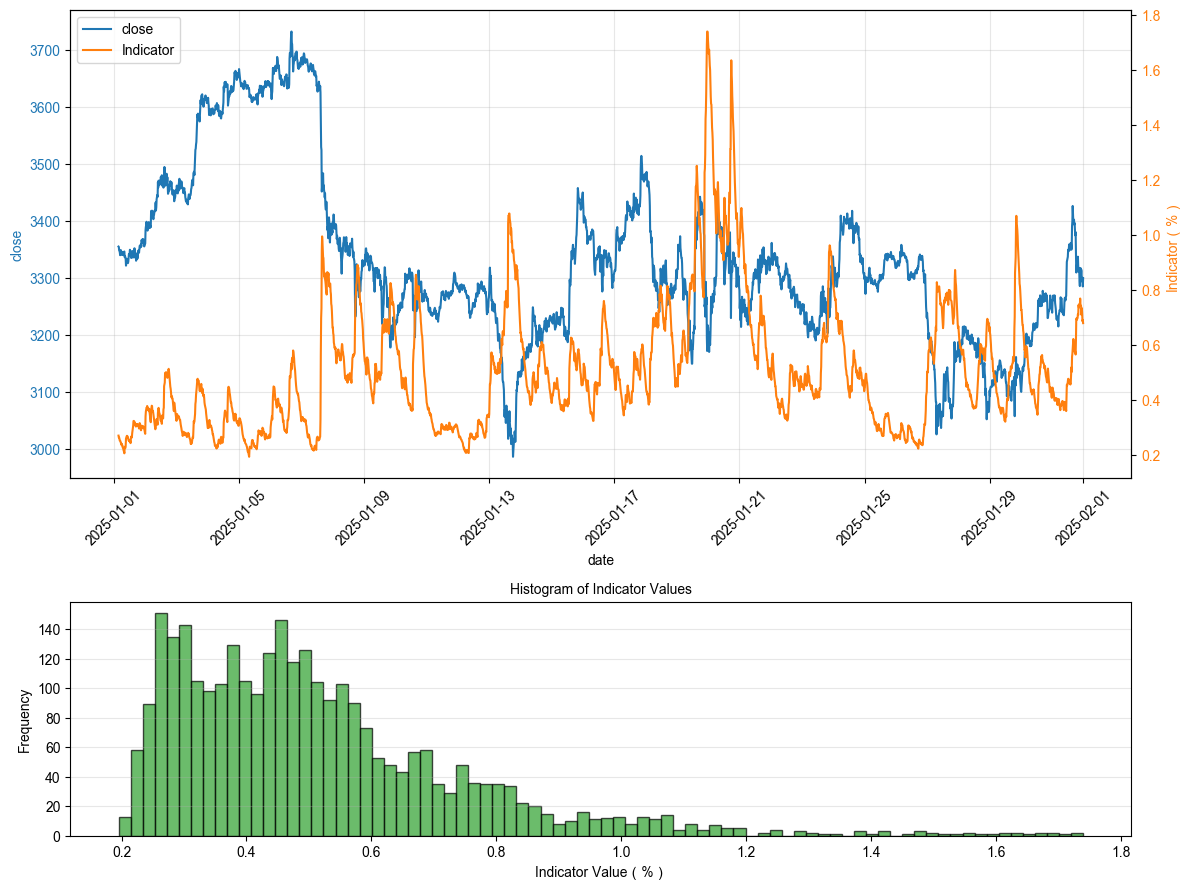

In [10]:
_ta_natr_14 = talib.NATR(high=high, low=low, close=close, timeperiod=14)
plot_twin(_ta_natr_14, df)

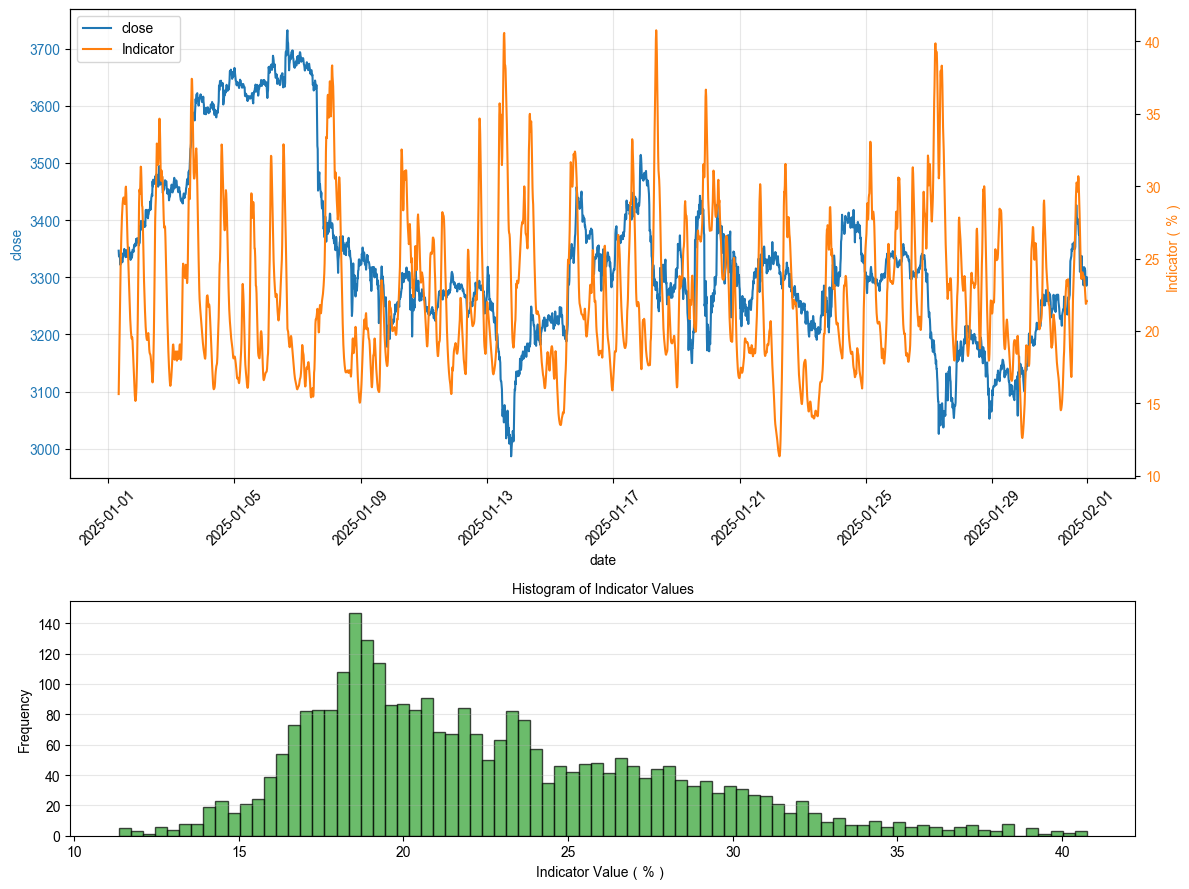

In [ ]:
_dcperiod = talib.HT_DCPERIOD(close)
plot_twin(_dcperiod, df)


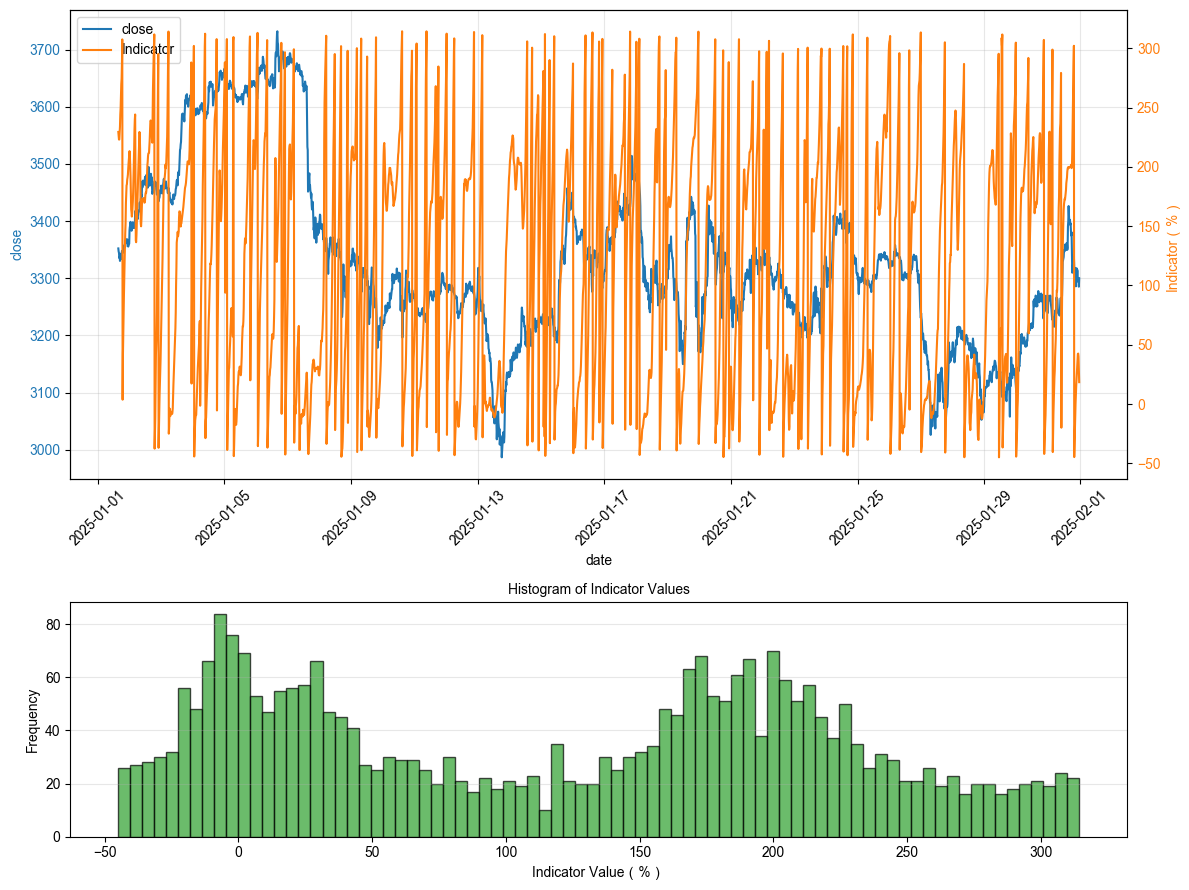

In [13]:
_dc_phase = talib.HT_DCPHASE(close)
plot_twin(_dc_phase, df)

In [ ]:
# 下单用GNN
